## Cardiovascular Disease Prediction: Clinical ML for Early Detection¶

**Author**: Dean | Lead Data & AI Engineer
**Focus**: Healthcare ML for clinical decision support in government and enterprise health systems

---

Cardiovascular disease (CVD) remains the leading cause of death globally. Early prediction using routinely collected clinical data — blood pressure, cholesterol, BMI, lifestyle factors — can flag high-risk patients before a cardiac event occurs.

This notebook builds a **production-grade binary classifier** to predict cardiovascular disease presence from 70,000 patient records. The framing is clinical/enterprise:

- How does this integrate with **Electronic Health Records (EHR)** and **FHIR** standards?
- What do clinicians need from model outputs? (Not just a score — calibrated probabilities, risk tiers, explainable features.)
- How do we handle model fairness across demographic groups?
- How does this align with TGA (Therapeutic Goods Administration) requirements for AI/ML in Australian healthcare?


In [11]:
import os, warnings, time, glob
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, brier_score_loss,
    log_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 6), 'axes.titlesize': 14,
    'axes.labelsize': 12, 'font.size': 11, 'figure.dpi': 100,
})

C_HEALTHY = '#2ecc71'
C_DISEASE = '#e74c3c'
C_PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6',
             '#1abc9c', '#e67e22', '#2c3e50']

print("Environment ready ✓")

Environment ready ✓


In [12]:
df_raw = pd.read_csv("cardio_train.csv", sep=";")

In [13]:
df_raw.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [14]:
info_df = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'non_null': df_raw.notnull().sum(),
    'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'nunique': df_raw.nunique(),
    'min': df_raw.min(numeric_only=False),
    'max': df_raw.max(numeric_only=False),
})
info_df

,dtype,non_null,null_pct,nunique,min,max
id,int64,70000,0.0,70000,0.0,99999.0
age,int64,70000,0.0,8076,10798.0,23713.0
gender,int64,70000,0.0,2,1.0,2.0
height,int64,70000,0.0,109,55.0,250.0
weight,float64,70000,0.0,287,10.0,200.0
ap_hi,int64,70000,0.0,153,-150.0,16020.0
ap_lo,int64,70000,0.0,157,-70.0,11000.0
cholesterol,int64,70000,0.0,3,1.0,3.0
gluc,int64,70000,0.0,3,1.0,3.0
smoke,int64,70000,0.0,2,0.0,1.0


In [15]:
TARGET = 'cardio' if 'cardio' in df_raw.columns else df_raw.columns[-1]
print(f"Target: '{TARGET}'")
print(f"\nClass distribution:")
vc = df_raw[TARGET].value_counts()
for cls, cnt in vc.items():
    label = 'Healthy' if cls == 0 else 'CVD Present'
    print(f" {cls} ({label}): {cnt:,} ({cnt/len(df_raw)*100:.1f}%)")
    print(f"\n Balance ratio: {vc.min() / vc.max():.3f}")

Target: 'cardio'

Class distribution:
 0 (Healthy): 35,021 (50.0%)

 Balance ratio: 0.999
 1 (CVD Present): 34,979 (50.0%)

 Balance ratio: 0.999


#### 2 · Exploratory Data Analysis

Understanding the clinical profile of CVD patients is essential before modelling. Key questions:

- Demographics: What age/gender distribution do we see?
- Clinical measurements: How do blood pressure, cholesterol, and BMI differ between groups?
- Lifestyle factors: Do smoking, alcohol, and physical activity show clear associations?
- Data quality: Are there outliers (e.g., impossible blood pressure values)?


In [16]:
# 2·1 — Data cleaning: handle known issues with this dataset
# Age is in days → convert to years
if 'age' in df_raw.columns and df_raw['age'].max() > 200:
    df_raw['age_years'] = (df_raw['age'] / 365.25).round(1)
    print(f"Converted age from days to years: range [{df_raw['age_years'].min():.0f}, {df_raw['age_years'].max():.0f}]")

# Blood pressure outliers (physiologically impossible values)
if 'ap_hi' in df_raw.columns:
    before = len(df_raw)
    # Remove extreme outliers
    df_clean = df_raw[
        (df_raw['ap_hi'] > 60) & (df_raw['ap_hi'] < 250) &
        (df_raw['ap_lo'] > 30) & (df_raw['ap_lo'] < 200) &
        (df_raw['ap_hi'] > df_raw['ap_lo'])  # systolic must be > diastolic
    ].copy()
    removed = before - len(df_clean)
    print(f"Removed {removed:,} rows with physiologically impossible BP values ({removed/before*100:.1f}%)")
else:
    df_clean = df_raw.copy()

# Remove height/weight outliers
if 'height' in df_clean.columns:
    df_clean = df_clean[(df_clean['height'] > 100) & (df_clean['height'] < 220)]
if 'weight' in df_clean.columns:
    df_clean = df_clean[(df_clean['weight'] > 30) & (df_clean['weight'] < 250)]

print(f"\nClean dataset: {len(df_clean):,} rows ({len(df_clean)/len(df_raw)*100:.1f}% retained)")

# Drop duplicates
n_dup = df_clean.duplicated().sum()
if n_dup > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Dropped {n_dup:,} duplicate rows → {len(df_clean):,} remaining")

Converted age from days to years: range [30, 65]
Removed 1,329 rows with physiologically impossible BP values (1.9%)

Clean dataset: 68,632 rows (98.0% retained)


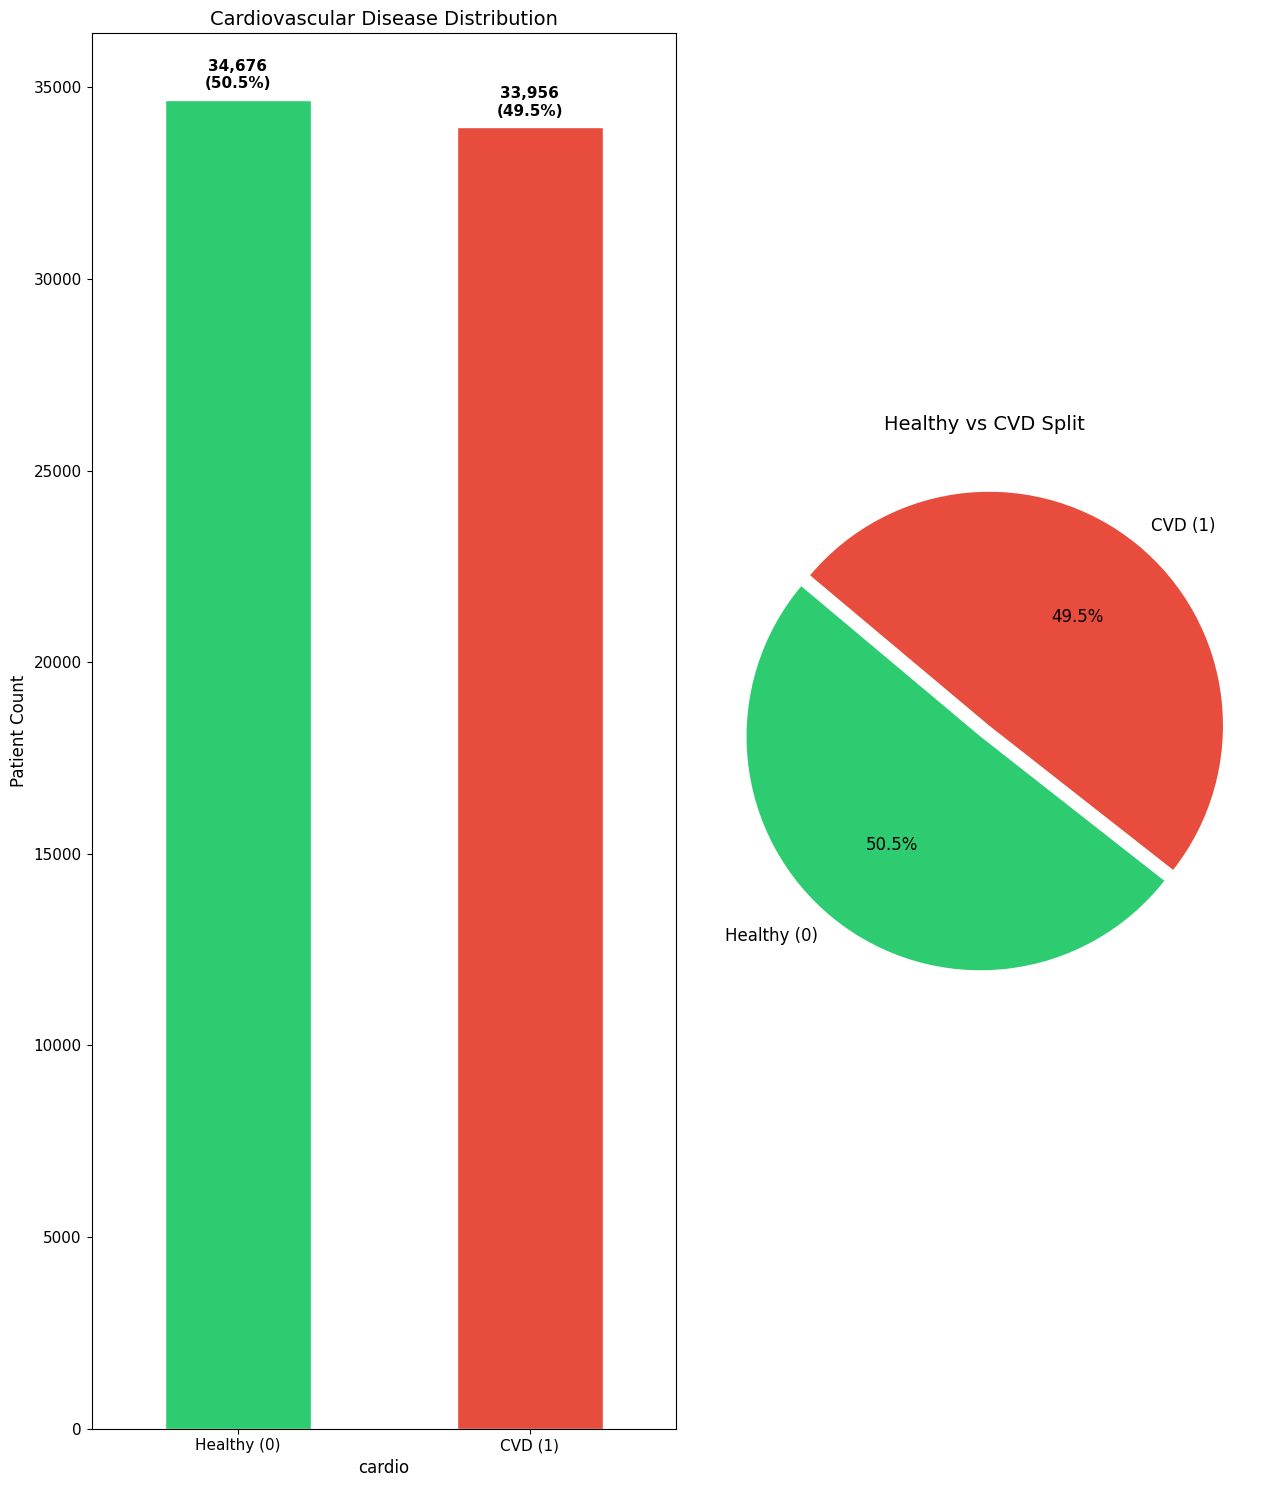

In [17]:
# 2.2 - Class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 15))

vc = df_clean[TARGET].value_counts()
labels = ['Healthy (0)', 'CVD (1)']
colors = [C_HEALTHY, C_DISEASE]

vc.plot.bar(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Cardiovascular Disease Distribution')
axes[0].set_ylabel('Patient Count')
axes[0].set_xticklabels(labels, rotation=0)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df_clean)*100:.1f}%)', 
                 ha='center', fontsize=11, fontweight='bold')
axes[1].pie(vc, labels=labels, autopct='%1.1f%%', colors=colors,
                startangle=140, textprops={'fontsize': 12}, explode=[0.03, 0.03])
axes[1].set_title('Healthy vs CVD Split')

plt.tight_layout()
plt.show()    

posx and posy should be finite values
posx and posy should be finite values


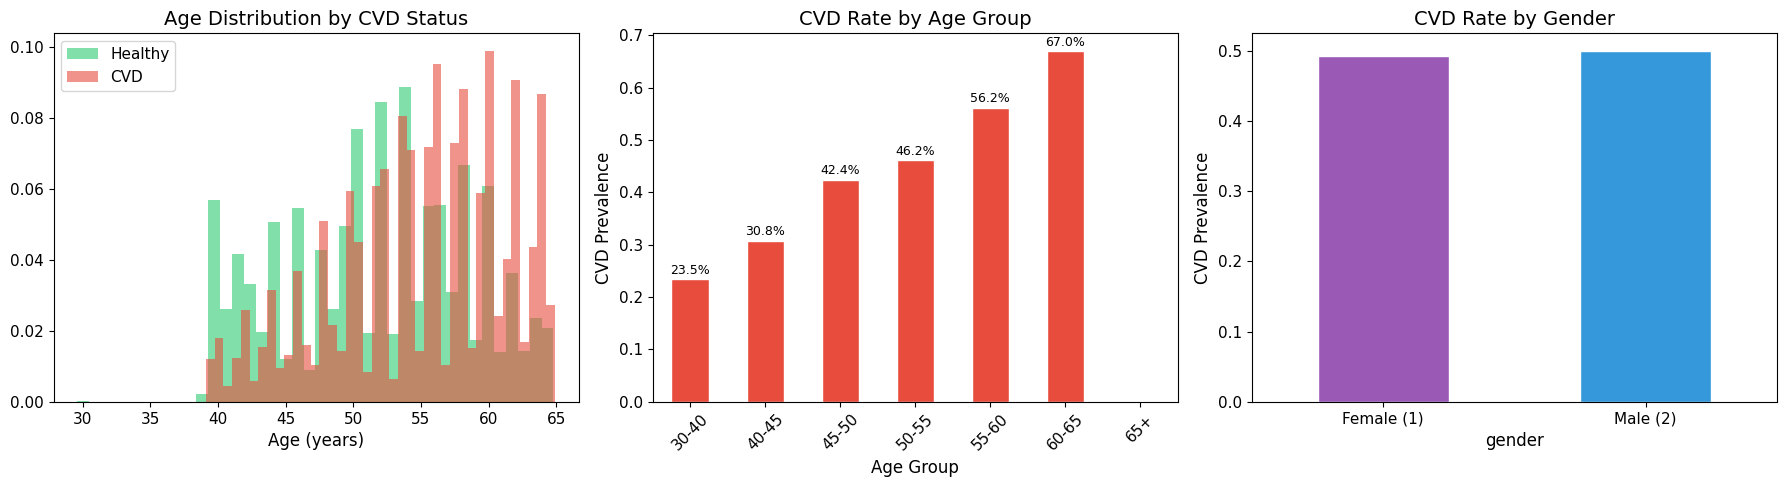

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_col = 'age_years' if 'age_years' in df_clean.columns else 'age'

# Age distribution by CD status
for status, color, label in [(0, C_HEALTHY, 'Healthy'), (1, C_DISEASE, 'CVD')]:
    # This is the same masking we discussed before — just grabbing the age column for one group at a time:
    subset = df_clean[df_clean[TARGET] == status][age_col]
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
    """
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
```

Breaking down each argument:
```
subset    → the age data to plot
bins=40   → split ages into 40 buckets (more bins = more detailed)
alpha=0.6 → 60% transparency so both histograms show through each other
color     → green for healthy, red for sick
label     → 'Healthy' or 'CVD' shown in the legend
density=True → show % of people instead of raw counts
               (so both groups are fairly compared even if sizes differ)
```

The `alpha=0.6` transparency is the key trick — it lets both histograms **overlap without hiding each other**:
```
Without alpha:          With alpha=0.6:
Green completely        Green and red
covers red ❌           blend where they overlap ✅
    
    """
axes[0].set_title('Age Distribution by CVD Status')
axes[0].set_xlabel('Age (years)' if 'years' in age_col else 'Age')
axes[0].legend()
    
# CVD rate by age group

if 'age_years' in df_clean.columns:
    df_clean['age_group'] = pd.cut(df_clean['age_years'], bins=[29, 40, 45, 50, 55, 60, 65, 100],
                                    labels=['30-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65+'])
    cvd_by_age = df_clean.groupby('age_group')[TARGET].mean()
    cvd_by_age.plot.bar(ax=axes[1], color=[C_DISEASE], edgecolor='white')
    axes[1].set_title('CVD Rate by Age Group')
    axes[1].set_ylabel('CVD Prevalence')
    axes[1].set_xlabel('Age Group')
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(cvd_by_age.values):
        axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

# Gender analysis
if 'gender' in df_clean.columns:
    gender_cvd = df_clean.groupby('gender')[TARGET].mean()
    gender_labels = ['Female (1)', 'Male (2)'] if set (df_clean['gender'].unique()) == {1, 2} else [str(g) for g in gender_cvd.index]
    gender_cvd.plot.bar(ax=axes[2], color=['#9b59b6', '#3498db'], edgecolor = 'white')
    axes[2].set_title('CVD Rate by Gender')
    axes[2].set_ylabel('CVD Prevalence')
    axes[2].set_xticklabels(gender_labels, rotation=0)
    
plt.tight_layout()
plt.show()
        

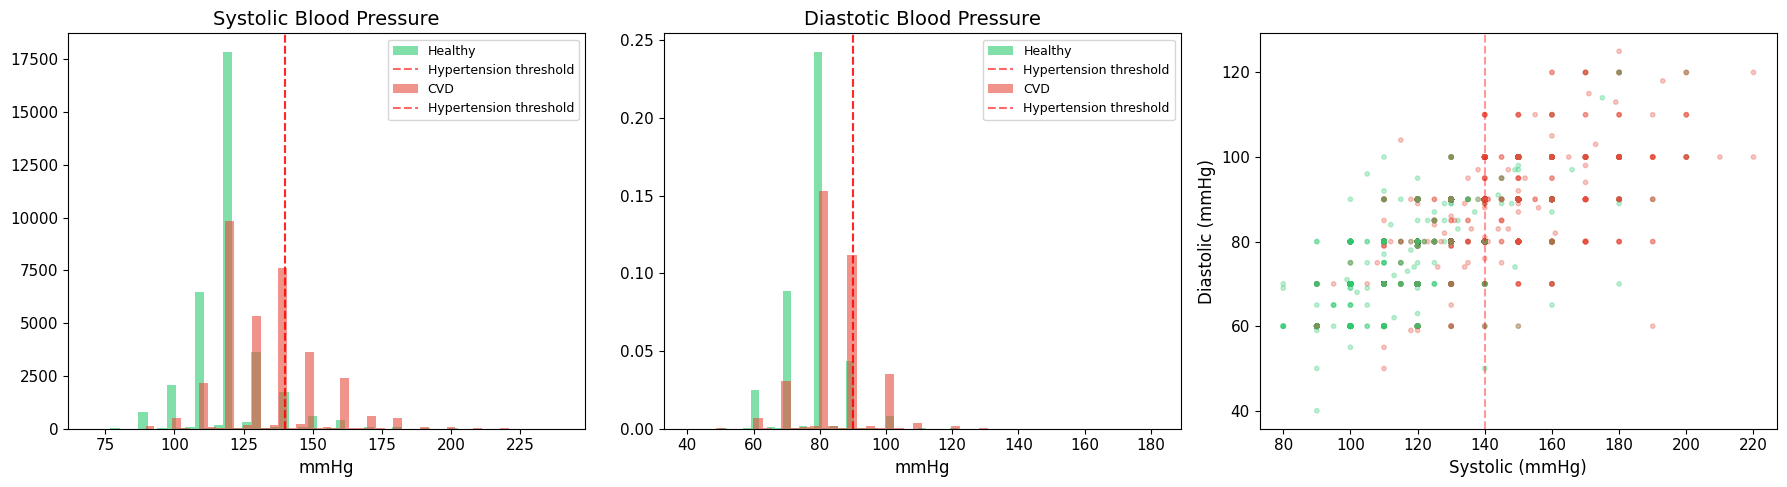

In [ ]:
# 2.4 - Blood pressure analysis

if 'ap_hi' in df_clean.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Systolic BP by CVD status
    for status, color, label in [(0, C_HEALTHY, 'Healthy'), (1, C_DISEASE, 'CVD')]:
        subset = df_clean[df_clean[TARGET] == status]['ap_hi']
        ## Since the code uses density=True, the Y axis shows probability density — basically the percentage of people at each blood pressure value.
        axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
        axes[0].set_title('Systolic Blood Pressure')
        axes[0].set_xlabel('mmHg')
        axes[0].axvline(x=140, color='red', linestyle='--', alpha=0.6, label='Hypertension threshold')
        axes[0].legend(fontsize=9)
    
    # Diastolic BP
    for status, color, label in [(0, C_HEALTHY, 'Healthy'), (1, C_DISEASE, 'CVD')]:
        subset = df_clean[df_clean[TARGET] == status]['ap_lo']
        axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
        axes[1].set_title('Diastotic Blood Pressure')
        axes[1].set_xlabel('mmHg')
        axes[1].axvline(x=90, color='red', linestyle='--', alpha=0.6, label='Hypertension threshold')
        axes[1].legend(fontsize=9)
    
    #BP scatter
    sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)
    scatter_colors = [C_HEALTHY if x == 0 else C_DISEASE for x in sample[TARGET]]
    
    axes[2].scatter(sample['ap_hi'], sample['ap_lo'], c=scatter_colors, alpha=0.3, s=10)
    axes[2].set_xlabel('Systolic (mmHg)')
    axes[2].set_ylabel('Diastolic (mmHg)')
    axes[2].axvline(x=140, color='red', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

In [ ]:
cat_features = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
cat_available = [c for c in cat_features if c in df_clean.columsn]